In [3]:
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/My Drive/Datasheet/credit_card_fraud_10k.csv'

Mounted at /content/drive


In [4]:
import pandas as pd

df = pd.read_csv(path)
df.head(10)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
5,6,30.53,13,Clothing,0,0,90,2,46,0
6,7,10.77,18,Travel,0,0,48,1,28,0
7,8,362.02,13,Electronics,0,0,68,1,40,0
8,9,165.43,8,Grocery,0,0,80,0,21,0
9,10,221.63,5,Grocery,0,0,59,1,34,0


In [5]:
df.tail(10)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9990,9991,107.74,12,Travel,1,0,26,2,39,0
9991,9992,70.78,18,Clothing,0,0,67,1,40,0
9992,9993,114.66,20,Travel,0,0,64,2,51,0
9993,9994,307.41,0,Grocery,0,1,92,1,26,0
9994,9995,23.96,22,Food,0,0,28,2,19,0
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [61]:
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("Data Types")
print("="*60)
print(df.dtypes)

print("\n")

print("="*60)
print("Summary")
print("="*60)
display(df.describe(include='all'))

Dataset Shape
(10000, 10)


Data Types
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object


Summary


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Food,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,2093,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,175.949849,11.593300,NaN,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,NaN,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,NaN,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,NaN,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,NaN,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,NaN,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000


In [7]:
baris, kolom = df.shape
print(f"Jumlah baris adalah {baris} dan jumlah kolom adalah {kolom}")

Jumlah baris adalah 10000 dan jumlah kolom adalah 10


In [8]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [9]:
missing = pd.DataFrame({
    'Missing' : df.isnull().sum(),
    'Percent' : df.isnull().mean()*100
})
missing[missing['Missing']>0]

,Missing,Percent


In [10]:
# Cek data duplikat
print(df.duplicated().sum())

0


In [12]:
df["is_fraud"].value_counts()

,count
is_fraud,
0,9849
1,151


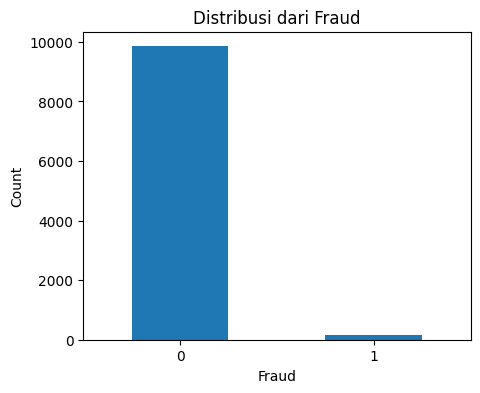

In [14]:
import matplotlib.pyplot as plt

fraud_counts = df['is_fraud'].value_counts()
plt.figure(figsize=(5,4))
fraud_counts.plot(kind='bar', rot=0)
plt.title("Distribusi dari Fraud")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.show()

In [15]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


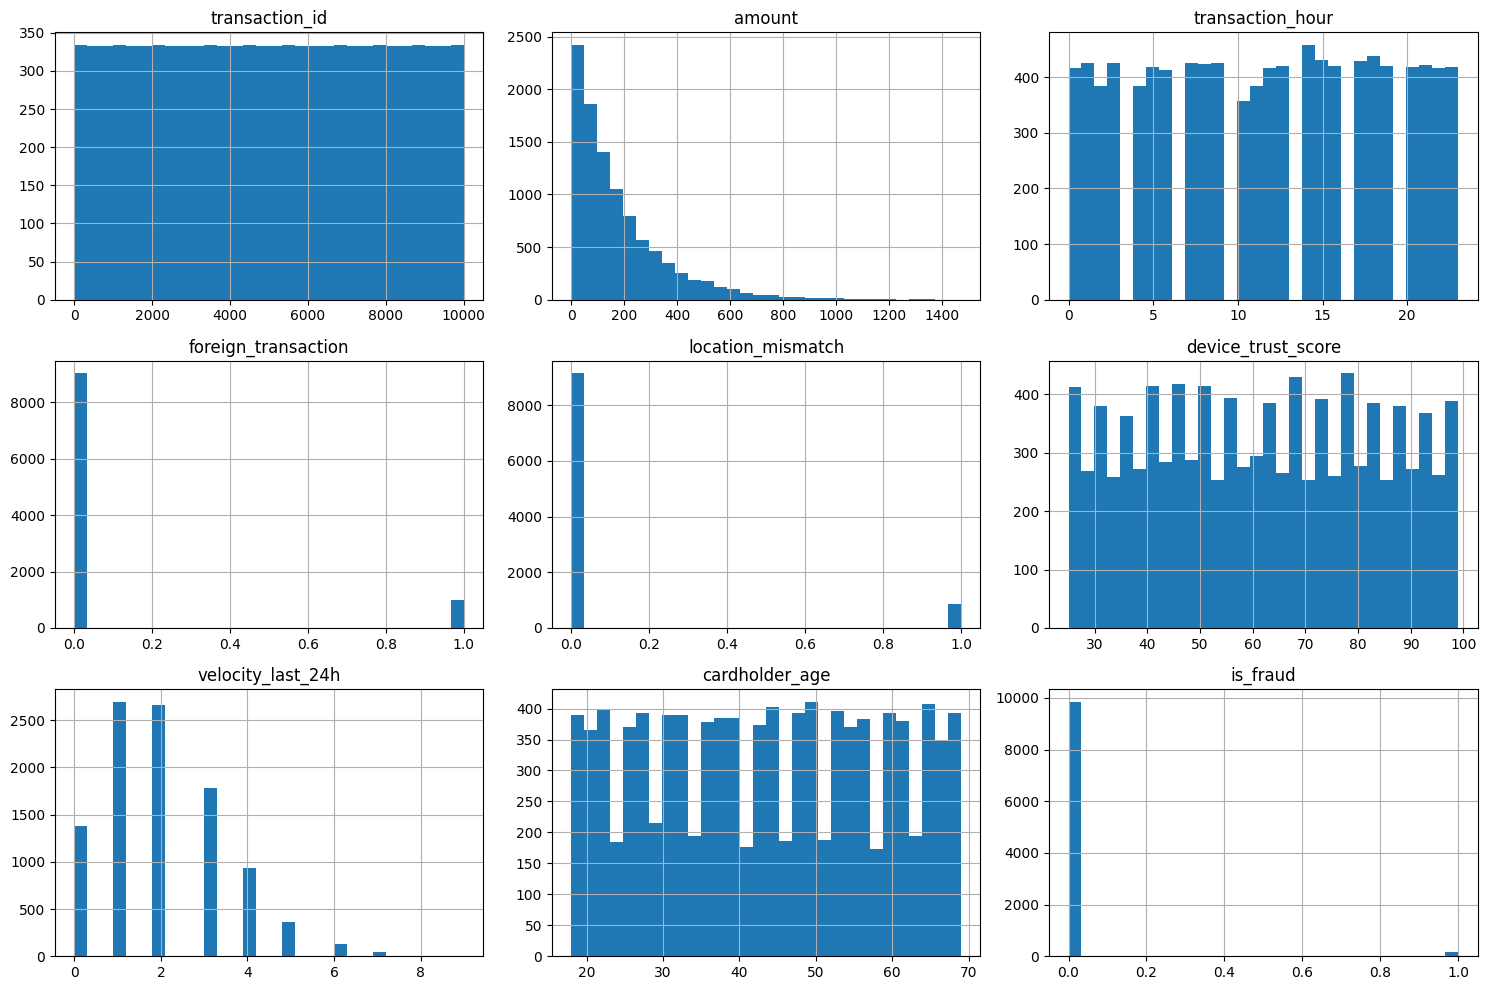

In [16]:
numeric_columns = df.select_dtypes(include='number').columns

df[numeric_columns].hist(
    figsize=(15,10),
    bins=30
)
plt.tight_layout()
plt.show()

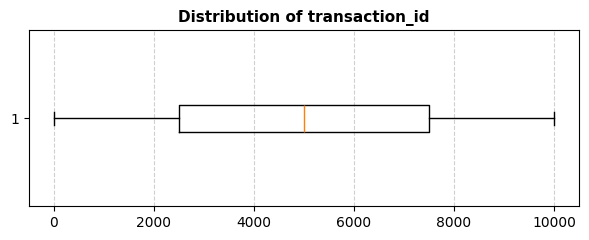

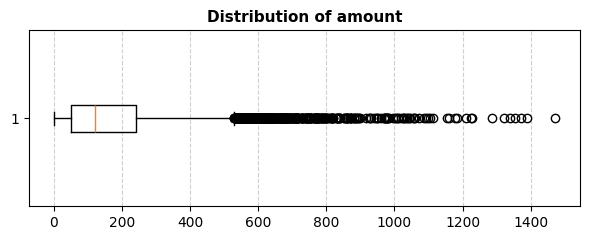

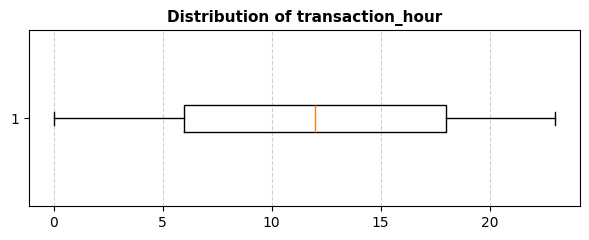

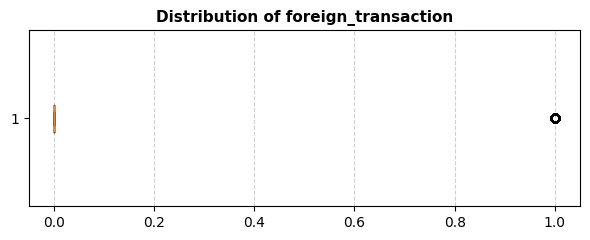

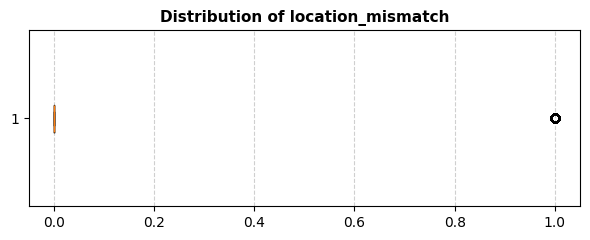

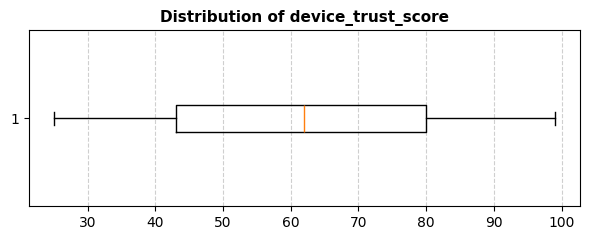

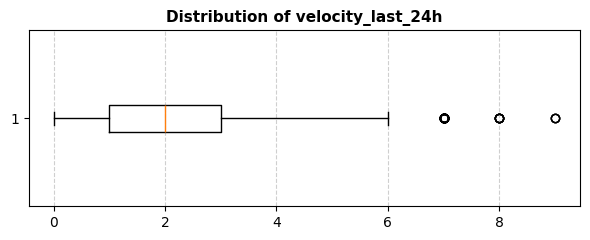

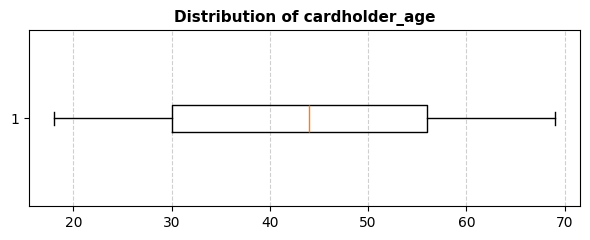

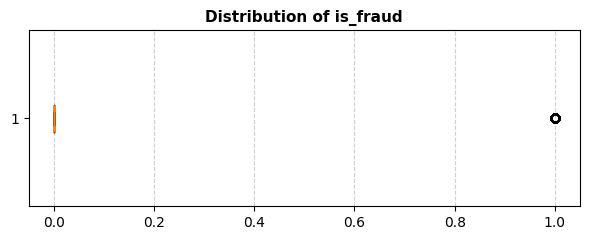

In [18]:
# Mencari Outlier
import matplotlib.pyplot as plt

for col in numeric_columns:
    plt.figure(figsize=(6, 2.5))
    plt.boxplot(df[col], vert=False)

    plt.title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    plt.grid(axis="x", linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

In [22]:
df['cardholder_age'].unique()

array([40, 64, 61, 34, 44, 46, 28, 21, 25, 68, 43, 69, 66, 24, 51, 49, 30,
       53, 35, 47, 18, 52, 20, 65, 42, 50, 33, 31, 60, 62, 22, 38, 23, 41,
       45, 59, 39, 57, 27, 54, 67, 26, 29, 56, 32, 55, 48, 36, 19, 63, 37,
       58])

In [25]:
umur_kartu = sorted(df['cardholder_age'].unique())
print(umur_kartu)

[np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69)]


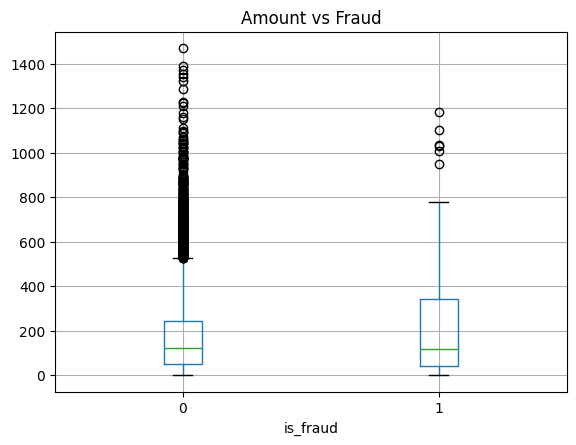

In [26]:
df.boxplot(column='amount', by='is_fraud')
plt.title('Amount vs Fraud')
plt.suptitle("")
plt.show()

In [46]:
df.groupby('is_fraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,9849.0,175.333015,173.986837,0.00,50.99,122.11,241.650,1471.04
1,151.0,216.182980,248.120467,0.11,41.53,118.94,341.695,1185.07


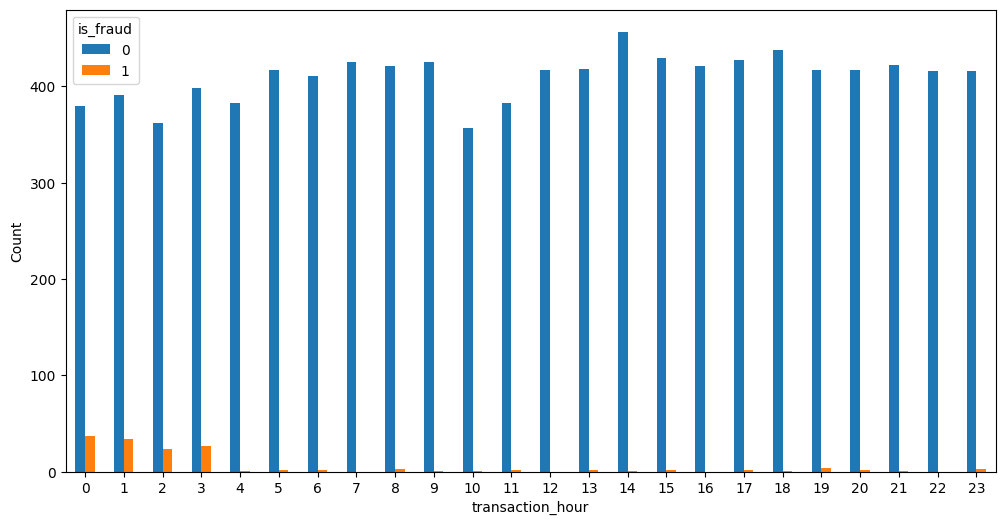

In [29]:
hour_fraud = pd.crosstab(
    df['transaction_hour'],
    df['is_fraud']
)
hour_fraud.plot(
    kind='bar',
    rot = 0,
    figsize=(12,6)
)
plt.ylabel("Count")
plt.show()

In [51]:
fraud_transaction_hour_rate = (
    df.groupby('transaction_hour')['is_fraud'].mean()
    .sort_values(ascending=False)
)
fraud_transaction_hour_rate

,is_fraud
transaction_hour,
0,0.088729
1,0.080000
3,0.063529
2,0.059740
19,0.009501
23,0.007160
8,0.007075
11,0.005195
6,0.004843


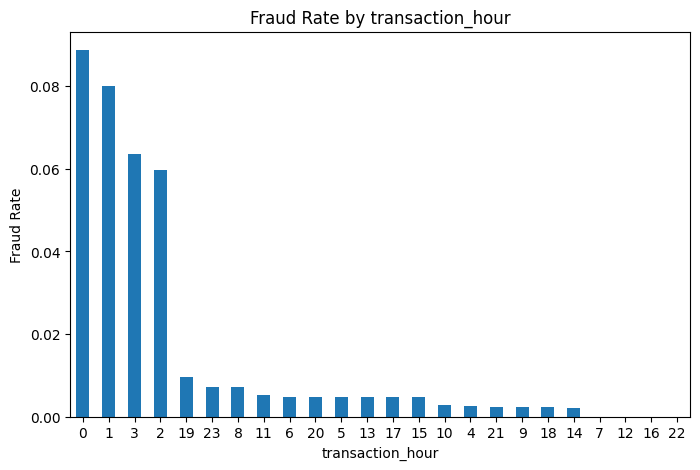

In [52]:
fraud_transaction_hour_rate.plot(
    kind='bar', rot = 0,
    figsize=(8,5)
)
plt.ylabel("Fraud Rate")
plt.xlabel('transaction_hour')
plt.title('Fraud Rate by transaction_hour')
plt.show()

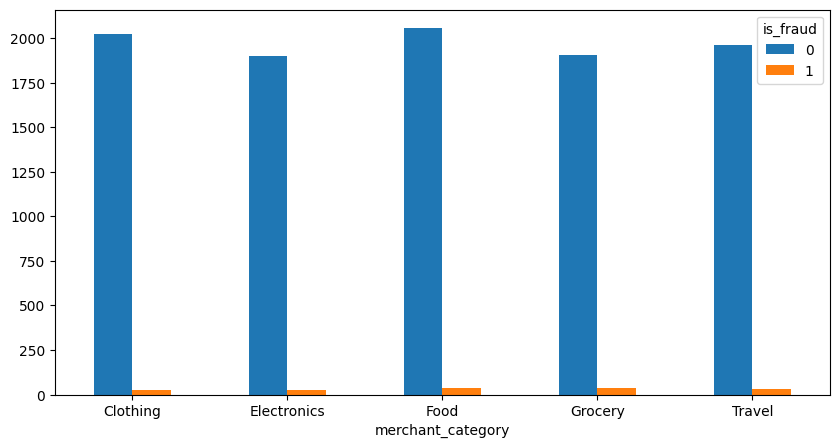

In [31]:
merchant = pd.crosstab(
    df['merchant_category'],
    df['is_fraud']
)
merchant.plot(
    kind='bar',
    rot=0,
    figsize=(10,5)
)
plt.show()

In [48]:
fraud_merchant_rate = (
    df.groupby('merchant_category')['is_fraud'].mean()
    .sort_values(ascending=False)
)
fraud_merchant_rate

,is_fraud
merchant_category,
Grocery,0.020062
Food,0.016722
Travel,0.014573
Electronics,0.012480
Clothing,0.011707


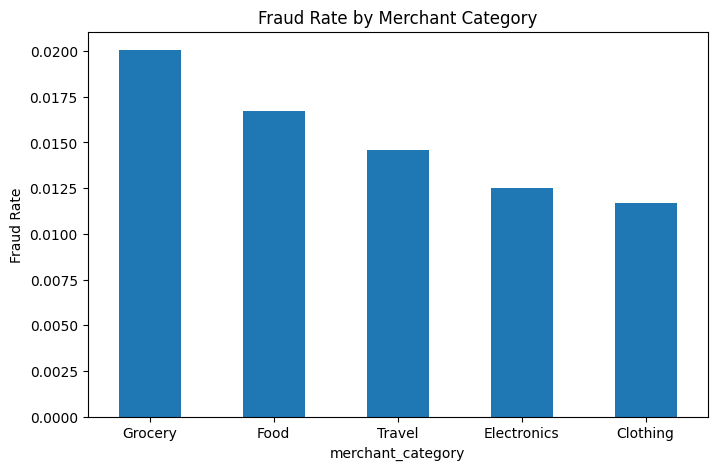

In [50]:
fraud_merchant_rate.plot(
    kind='bar',rot=0,
    figsize=(8,5)
)

plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Merchant Category")
plt.show()

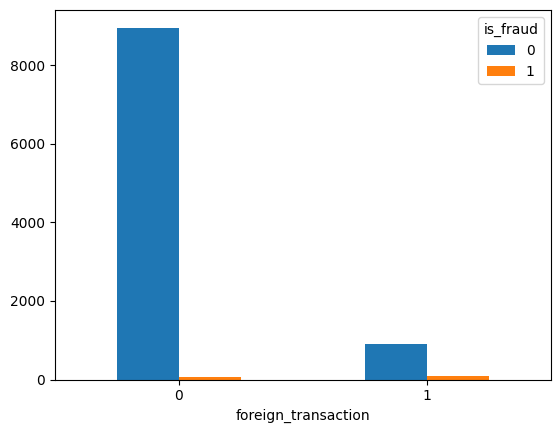

In [33]:
foreign = pd.crosstab(
    df['foreign_transaction'],
    df['is_fraud']
)
foreign.plot(kind='bar',rot=0)
plt.show()

In [53]:
fraud_foreign_transaction_rate = (
    df.groupby('foreign_transaction')['is_fraud'].mean()
    .sort_values(ascending=False)
)
fraud_foreign_transaction_rate

,is_fraud
foreign_transaction,
1,0.083845
0,0.007648


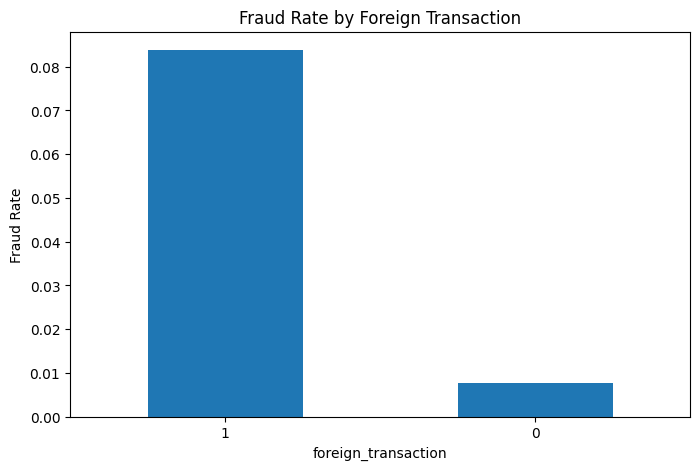

In [54]:
fraud_foreign_transaction_rate.plot(
    kind='bar',rot=0,
    figsize=(8,5)
)
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Foreign Transaction')
plt.show()

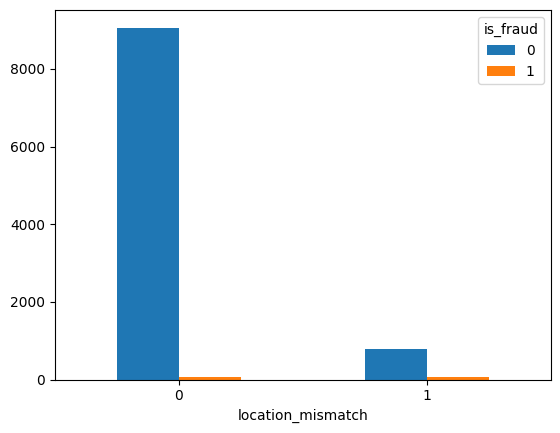

In [34]:
location = pd.crosstab(
    df['location_mismatch'],
    df['is_fraud']
)
location.plot(kind='bar', rot=0)
plt.show()

In [55]:
fraud_location_mismatch = (
    df.groupby('location_mismatch')['is_fraud'].mean()
    .sort_values(ascending=False)
)
fraud_location_mismatch

,is_fraud
location_mismatch,
1,0.084014
0,0.008640


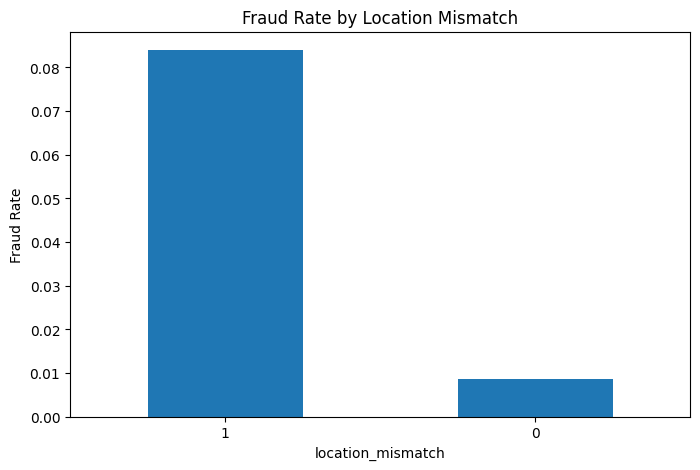

In [57]:
fraud_location_mismatch.plot(
    kind='bar', rot=0,
    figsize=(8,5)
)
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Location Mismatch')
plt.show()

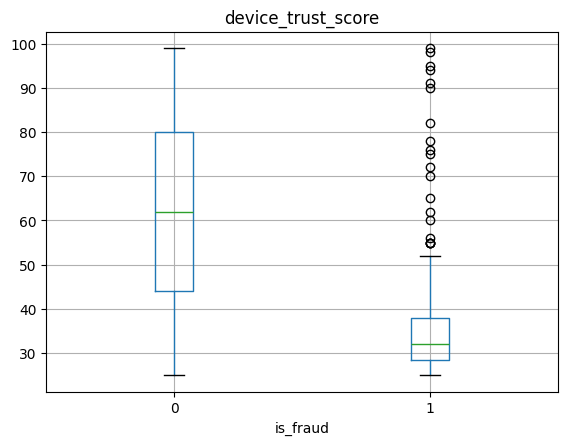

In [35]:
df.boxplot(
    column='device_trust_score',
    by='is_fraud'
)
plt.suptitle("")
plt.show()

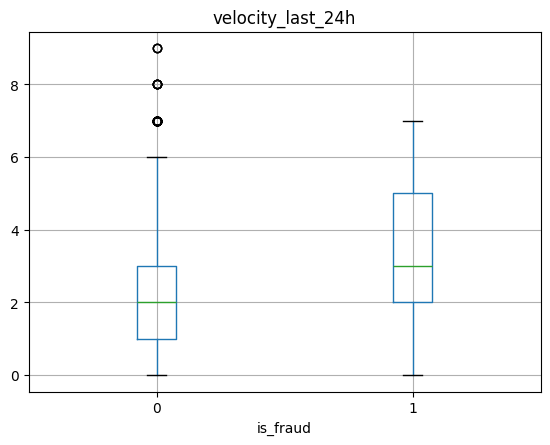

In [36]:
df.boxplot(
    column='velocity_last_24h',
    by='is_fraud'
)
plt.suptitle("")
plt.show()

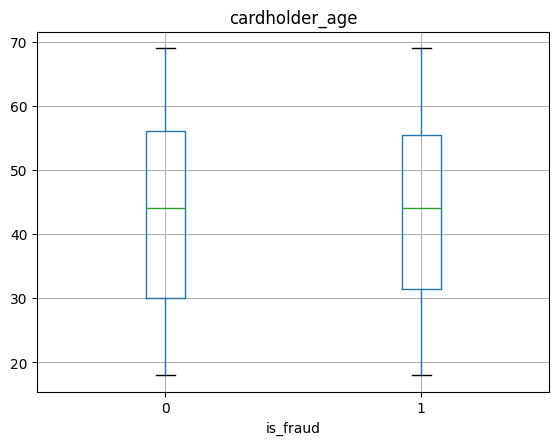

In [40]:
df.boxplot(
    column='cardholder_age',
    by='is_fraud'
)
plt.suptitle("")
plt.show()

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [88]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, dtype=int)
encoder_merchant = encoder.fit_transform(df[['merchant_category']])
df_encoder = pd.DataFrame(encoder_merchant, columns=encoder.get_feature_names_out(['merchant_category']),index=df.index)

In [89]:
# Gabungkan
df_e = pd.concat([df, df_encoder],axis=1)

In [90]:
df_e.head(5)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,merchant_category_Clothing,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,1,84.47,22,Electronics,0,0,66,3,40,0,0,1,0,0,0
1,2,541.82,3,Travel,1,0,87,1,64,0,0,0,0,0,1
2,3,237.01,17,Grocery,0,0,49,1,61,0,0,0,0,1,0
3,4,164.33,4,Grocery,0,1,72,3,34,0,0,0,0,1,0
4,5,30.53,15,Food,0,0,79,0,44,0,0,0,1,0,0


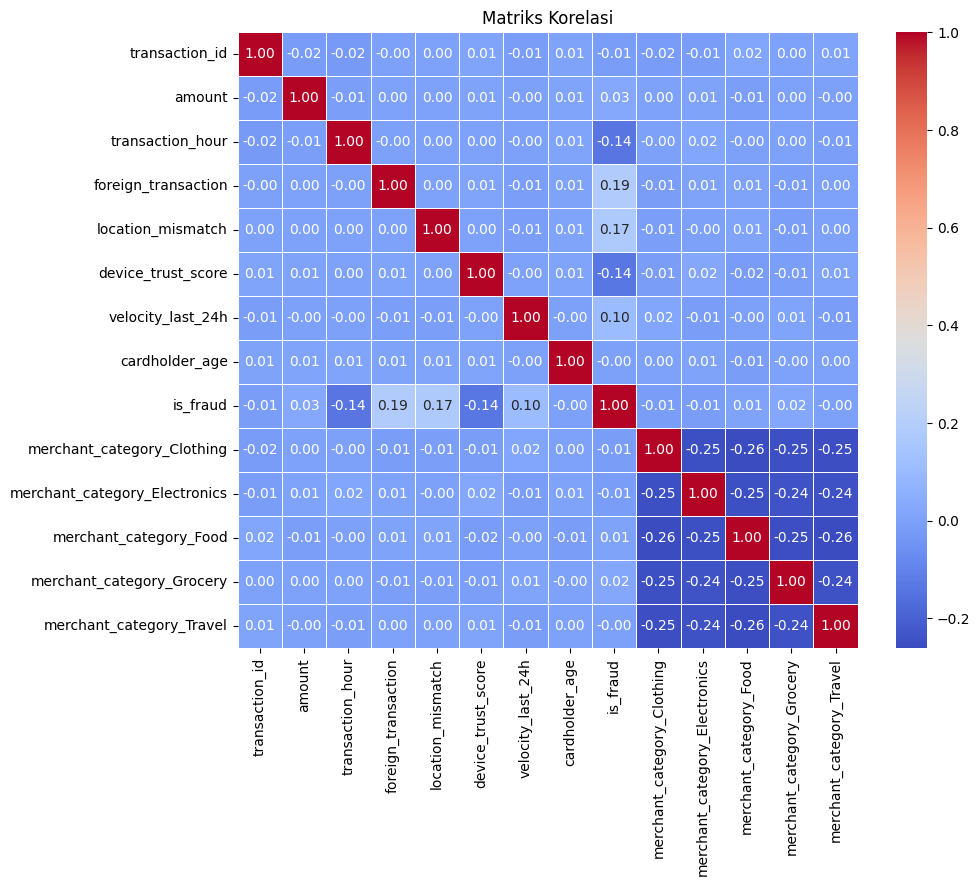

In [92]:
import seaborn as sns
# Korelasi
corr = df_e.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi")
plt.show()

In [93]:
pivot_transaction_hour = pd.pivot_table(
    df,
    index='transaction_hour',
    columns='foreign_transaction',
    values='is_fraud',
    aggfunc='mean'
)
pivot_transaction_hour

foreign_transaction,0,1
transaction_hour,,
0,0.056300,0.363636
1,0.042440,0.375000
2,0.025641,0.411765
3,0.041558,0.275000
4,0.000000,0.027778
5,0.000000,0.045455
6,0.002681,0.025000
7,0.000000,0.000000
8,0.000000,0.068182


In [94]:
pd.crosstab(
    df['transaction_hour'],
    df['foreign_transaction']
)

foreign_transaction,0,1
transaction_hour,,
0,373,44
1,377,48
2,351,34
3,385,40
4,348,36
5,375,44
6,373,40
7,387,38
8,380,44


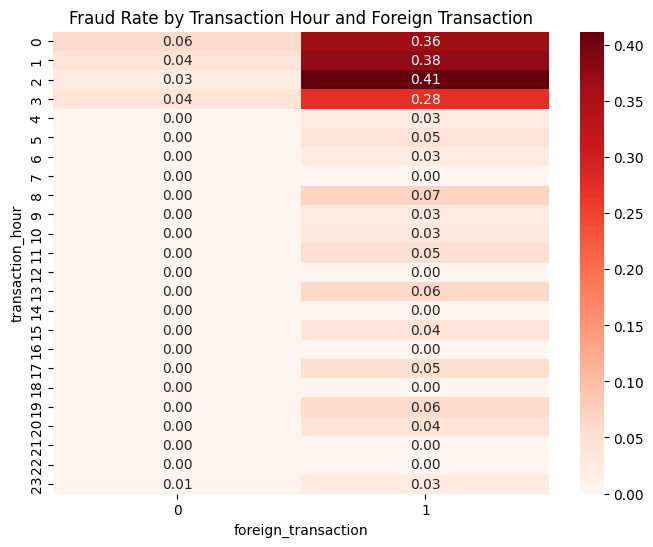

In [95]:
plt.figure(figsize=(8,6))
sns.heatmap(pivot_transaction_hour, annot=True, fmt=".2f", cmap="Reds")
plt.title("Fraud Rate by Transaction Hour and Foreign Transaction")
plt.show()

In [96]:
pivot_merchant = pd.pivot_table(
    df,
    index='merchant_category',
    columns='foreign_transaction',
    values='is_fraud',
    aggfunc='mean'
)
pivot_merchant

foreign_transaction,0,1
merchant_category,,
Clothing,0.006982,0.058511
Electronics,0.007532,0.055838
Food,0.008515,0.088785
Grocery,0.009637,0.122222
Travel,0.005583,0.095477


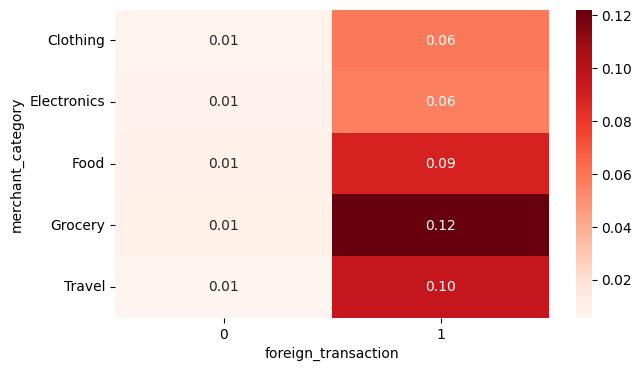

In [97]:
plt.figure(figsize=(7,4))
sns.heatmap(
    pivot_merchant,
    annot=True,
    cmap='Reds',
    fmt='.2f'
)

plt.show()

In [98]:
from scipy.stats import mannwhitneyu

normal = df[df.is_fraud==0]['amount']
fraud = df[df.is_fraud==1]['amount']

stat,p = mannwhitneyu(normal,fraud)
print("Statistic :", stat)
print("P-Value :", p)

Statistic : 723703.0
P-Value : 0.5719837703357644


In [99]:
normal = df[df.is_fraud==0]['device_trust_score']
fraud = df[df.is_fraud==1]['device_trust_score']

stat,p = mannwhitneyu(normal,fraud)
print("Statistic :", stat)
print("P-Value :", p)

Statistic : 1229406.0
P-Value : 2.5400688822040263e-43


In [100]:
normal = df[df.is_fraud==0]['cardholder_age']
fraud = df[df.is_fraud==1]['cardholder_age']

stat,p = mannwhitneyu(normal,fraud)
print("Statistic :", stat)
print("P-Value :", p)

Statistic : 745553.0
P-Value : 0.9557528794271394


In [104]:
df_feature = df_e.drop(columns=['transaction_id','merchant_category'])

In [105]:
df_e.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   transaction_id                 10000 non-null  int64  
 1   amount                         10000 non-null  float64
 2   transaction_hour               10000 non-null  int64  
 3   merchant_category              10000 non-null  object 
 4   foreign_transaction            10000 non-null  int64  
 5   location_mismatch              10000 non-null  int64  
 6   device_trust_score             10000 non-null  int64  
 7   velocity_last_24h              10000 non-null  int64  
 8   cardholder_age                 10000 non-null  int64  
 9   is_fraud                       10000 non-null  int64  
 10  merchant_category_Clothing     10000 non-null  int64  
 11  merchant_category_Electronics  10000 non-null  int64  
 12  merchant_category_Food         10000 non-null  

In [106]:
from sklearn.ensemble import RandomForestClassifier

X = df_feature.drop(columns='is_fraud')
y = df['is_fraud']
rf= RandomForestClassifier(random_state=42)
rf.fit(X,y)

RandomForestClassifier(random_state=42)

In [107]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance

,Feature,Importance
4,device_trust_score,0.233308
1,transaction_hour,0.186146
2,foreign_transaction,0.126805
5,velocity_last_24h,0.123015
3,location_mismatch,0.121838
0,amount,0.104673
6,cardholder_age,0.065754
10,merchant_category_Grocery,0.010400
11,merchant_category_Travel,0.009304
8,merchant_category_Electronics,0.006547


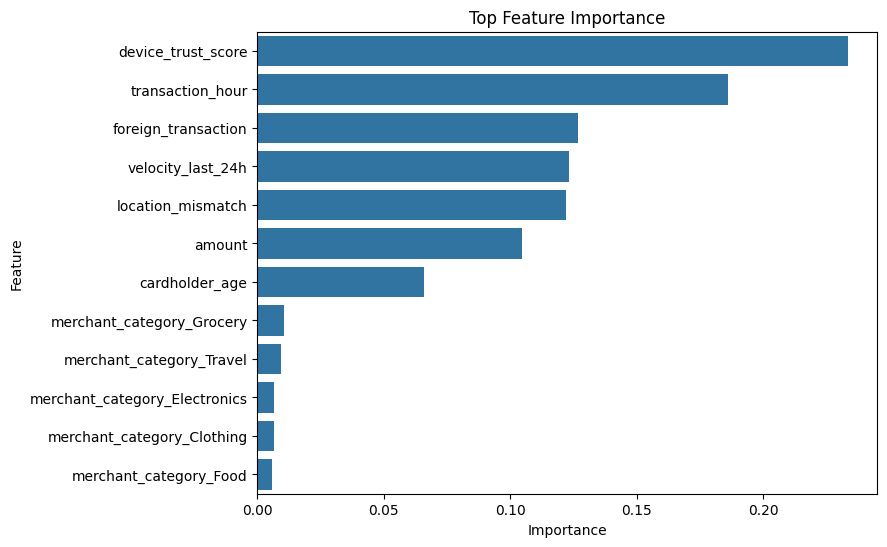

In [108]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=importance.head(15),
    y='Feature',
    x='Importance'
)
plt.title("Top Feature Importance")
plt.show()